In [1]:
import numpy as np
import matplotlib.pyplot as plt

Expectation 
$$\mathbb{E}[X] = \sum_{n=1}^\infty\frac{1}{2^n}\cdot 2^n = \sum_{n=1}^\infty 1 = \infty$$

Emolumentum Medium

$$\mathbb{E}[U(X)] = \sum_{n=1}^\infty\frac{1}{2^n}\cdot \log(2^n) = \log(2)\sum_{n=1}^\infty\frac{n}{2^n}$$

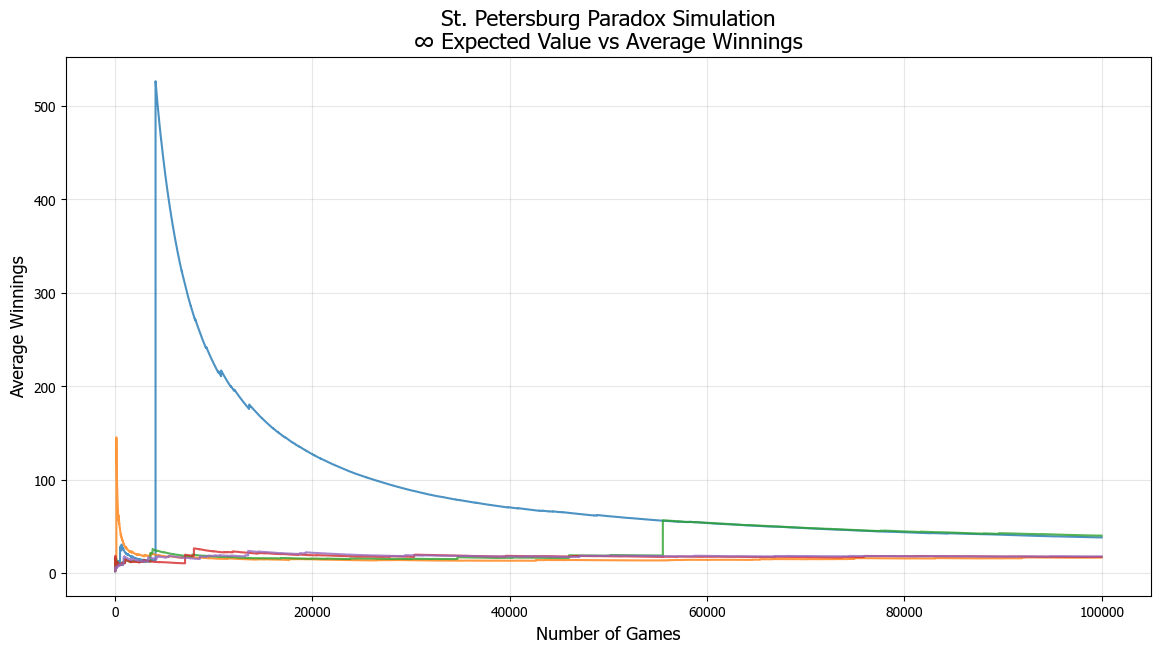

In [2]:
# Use Tahoma font like the video
plt.rcParams["font.family"] = "Tahoma"
np.random.seed(9)

def st_petersburg_game():
    flips = 1
    while np.random.rand() > 0.5:
        flips += 1
    return 2 ** flips

# Parameters
n_games = 100_000
n_paths = 5  # multiple simulations for variability

# Store results
all_averages = []

for _ in range(n_paths):
    winnings = []
    running_avg = []
    total = 0
    for i in range(1, n_games + 1):
        win = st_petersburg_game()
        total += win
        running_avg.append(total / i)
    all_averages.append(running_avg)

# Plotting
plt.figure(figsize=(14, 7))
for avg in all_averages:
    plt.plot(avg, alpha=0.8)

plt.title("St. Petersburg Paradox Simulation\n∞ Expected Value vs Average Winnings", fontsize=16)
plt.xlabel("Number of Games", fontsize=13)
plt.ylabel("Average Winnings", fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()


In [3]:
# keys are the numbers from a dice
# values are results of gambling
payoff = {1: 1, 2: 2, 3: 6, 4: 22, 5: 200, 6: 1_000_000}

In [4]:
E_X = sum([payoff[i] for i in payoff]) / len(payoff)
E_X

166705.16666666666

In [5]:
init_wealth = 100_000
wager = 50_000

# arithematic average
E_ending_wealth = sum([init_wealth - wager + payoff[i] for i in payoff]) / len(payoff)
E_ending_wealth

216705.16666666666

In [6]:
E_log_ending_wealth =  sum([np.log(init_wealth - wager + payoff[i]) for i in payoff]) / len(payoff)
E_log_ending_wealth

np.float64(11.32796734341394)

In [7]:
# geometric average
geometric_mean = np.exp(E_log_ending_wealth)
geometric_mean

np.float64(83113.90899349027)

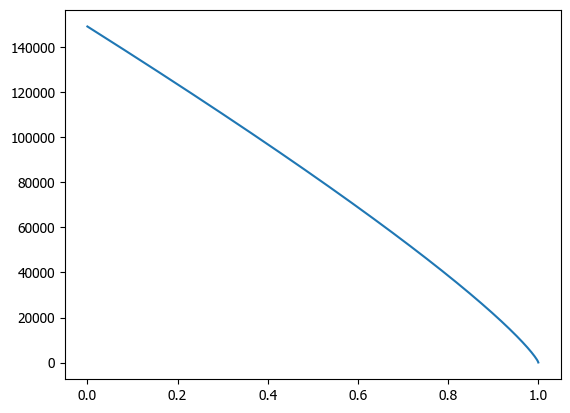

In [8]:
init_wealth = 100_000

num_step = 1001
geomatric_mean_arr = np.zeros(num_step)
wager_ratio = np.linspace(0, 1, num_step)

for i, w_r in enumerate(wager_ratio):
    wager = init_wealth * w_r
    E_log_ending_wealth =  sum([np.log(init_wealth - wager + payoff[i]) for i in payoff]) / len(payoff)
    geomatric_mean_arr[i] = np.exp(E_log_ending_wealth)

init_wealth * wager_ratio[np.argmin(abs(geomatric_mean_arr - 100_000))]

plt.plot(wager_ratio, geomatric_mean_arr)

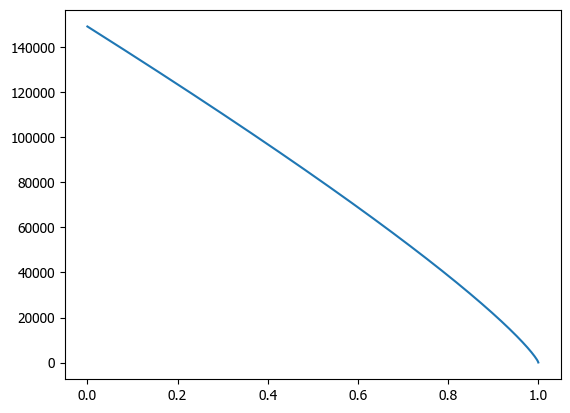

In [9]:
plt.plot(wager_ratio, geomatric_mean_arr)

In [10]:
init_wealth * wager_ratio[np.argmin(abs(geomatric_mean_arr - 100_000))]

np.float64(37700.0)

In [11]:
np.log(13000 - 800)

np.float64(9.409191230721348)

In [12]:
np.log(13000 / 12200)

np.float64(0.06351340572232593)

In [13]:
init_wealth = 10_000 + 3_000
insurance_cost = 800

wealths = []
log_wealths = []
for num_ship in range(0, 16):
    cost = insurance_cost * num_ship
    end_wealth = init_wealth - cost

    log_wealths.append(np.log(end_wealth))
    wealths.append(end_wealth)


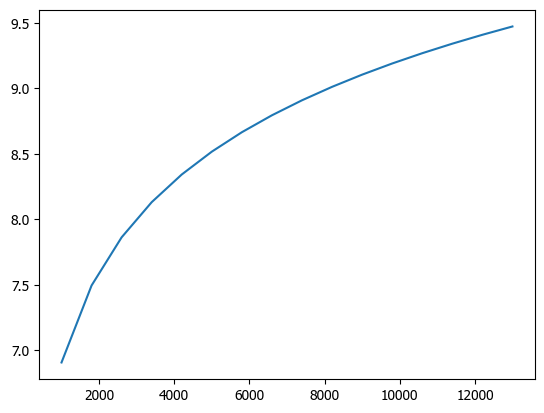

In [14]:
plt.plot(wealths, log_wealths)

In [18]:
100 * np.log(300)

np.float64(570.3782474656201)

In [19]:
5 * np.log(10_000)

np.float64(46.05170185988092)

In [23]:
init_log_wealth = np.log(10_000 + 3_000)
init_log_wealth

np.float64(9.472704636443673)

In [25]:
insurance_log_wealth = np.log(10_000 + 3_000 - 800)
insurance_log_wealth

np.float64(9.409191230721348)

In [27]:
without_insurance_log_wealth = np.log(10_000 + 3_000 - 10_000)
without_insurance_log_wealth

np.float64(8.006367567650246)

In [26]:
insurane_cost = init_log_wealth - insurance_log_wealth
insurane_cost

np.float64(0.06351340572232544)

In [28]:
without_insurance_cost = init_log_wealth - without_insurance_log_wealth
without_insurance_cost

np.float64(1.4663370687934272)

In [31]:
np.exp(insurane_cost * 100)

np.float64(573.2606914956903)

In [32]:
np.exp(without_insurance_cost * 5)

np.float64(1527.954732510289)